# FDM UVLF Demo: Plugging In Your Own Halo Mass Function

## Take This Notebook With A Grain Of Salt
It was not actually used in the paper and I'm writing it up quickly much after. It might have mistakes.

This notebook walks through the pipeline for fitting UV luminosity function (UVLF) data
using a conditional luminosity function (CLF) model. The key idea:

1. You have **observed UVLF data** (number density of galaxies vs magnitude at each redshift)
2. You have a **model** that predicts the UVLF given:
   - A halo mass function (HMF): $dn/dM$ — how many halos exist at each mass
   - A conditional luminosity function: $L_c(M, z)$ — how bright a halo of mass $M$ is
3. You **fit the model parameters** to the data using optimization and/or MCMC

**The main extension point**: override `dn_dM(M, z)` in a model subclass to use your own
halo mass function (e.g., a different FDM suppression, a different window function, etc.).

---

## Table of Contents
1. Setup & Data
2. The Forward Model (how predictions are made)
3. The CDM Baseline
4. Adding FDM: the `dn_dM` Override
5. Visualizing the Effect of FDM Mass
6. Optimization
7. MCMC Sampling
8. Reading Back Chains & Making Plots
9. Writing Your Own Model

## 1. Setup & Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import utils
import lf_model
import lf_optimizer
import lf_plotter
import mass_function
from lf_model import LFModel, FiducialCLF, ReciprocalFuzzyCLF, LFMeasurements
from lf_optimizer import LFOptimizer
from lf_plotter import LFPlotter

### What's in the measurement data?

Each model variant has a directory under `lf/by_name/<ModelName>/` containing:
- `meas.npz` — the observational UVLF data
- `best.npy` — best-fit parameter vector (from previous optimization)

The measurement file contains arrays of matching length:
- `z_vals` — redshift for each data point
- `mags` — UV magnitude bin center
- `phis` — observed number density $\phi(M_{\rm UV})$ [Mpc$^{-3}$ mag$^{-1}$]
- `sig_pluses`, `sig_minuses` — asymmetric $1\sigma$ error bars
- `sources` — which observational survey the point came from

In [2]:
path = './lf/by_name/'

# Load and inspect the measurement data
meas = LFMeasurements(path + 'FiducialCLF/meas.npz')
print(f"Total data points: {meas.n_points}")
print(f"Redshifts: {meas.unique_z}")
print(f"Sources: {sorted(set(meas.sources))}")
print(f"\nExample points at z=6:")
count = 0
for z, m, phi, sm, sp, src in meas.zipped:
    if z == 6 and count < 5:
        print(
            f"  M_UV={m:.1f}, phi={phi:.2e} (+{sp:.2e} / -{sm:.2e})  [{src}]")
        count += 1

Total data points: 111
Redshifts: [ 5.  6.  7.  8.  9. 10.]
Sources: ['B21', 'B22']

Example points at z=6:
  M_UV=-24.4, phi=1.41e-06 (+1.41e-06 / -1.41e-06)  [B21]
  M_UV=-23.7, phi=9.90e-06 (+3.54e-06 / -3.54e-06)  [B21]
  M_UV=-23.0, phi=3.61e-05 (+7.78e-06 / -7.78e-06)  [B21]
  M_UV=-22.3, phi=1.20e-04 (+1.70e-05 / -1.70e-05)  [B21]
  M_UV=-21.6, phi=2.24e-04 (+2.90e-05 / -2.90e-05)  [B21]


### The precomputed CDM halo mass function

`mass_fns.npz` contains the CDM halo mass function $dn/dM$ precomputed on a grid of
halo masses at each integer redshift. These were computed using the Sheth-Tormen
formalism with a CAMB power spectrum (`P_k.npz`).

The function `utils.load_mf()` returns a dictionary `{z: interpolator(M)}` where
each interpolator gives $dn/dM$ in units of Mpc$^{-3}$ $M_\odot^{-1}$.
We plot $M \cdot dn/dM = dn/d\ln M$ which shows the mass contribution per log interval.

Available redshifts: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 13.75, 14, 15, 16, 17, 18, 19]


/root/fdm-uvlf/utils.py:148: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)


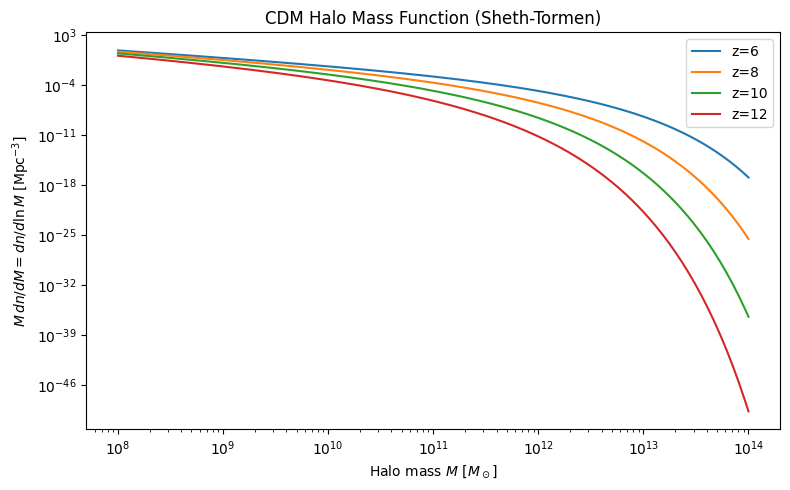

In [3]:
mf = utils.load_mf()
print(f"Available redshifts: {sorted(mf.keys())}")

M_vals = np.logspace(8, 14, 200)
plt.figure(figsize=(8, 5))
for z in [6, 8, 10, 12]:
    plt.loglog(M_vals, [M * mf[z](M) for M in M_vals], label=f'z={z}')
plt.xlabel(r'Halo mass $M$ [$M_\odot$]')
plt.ylabel(r'$M \, dn/dM = dn/d\ln M$ [Mpc$^{-3}$]')
plt.legend()
plt.title('CDM Halo Mass Function (Sheth-Tormen)')
plt.tight_layout()
plt.show()

## 2. The Forward Model

The model predicts the observed UVLF $\phi(M_{\rm UV}, z)$ through a chain of steps:

$$\phi(L, z) = \int_{M_{\rm min}}^{M_{\rm max}} \frac{dn}{dM}(M, z) \cdot \Phi(L | M, z) \, dM$$

where:
- $dn/dM$ is the **halo mass function** (this is what you swap out for FDM)
- $\Phi(L|M,z)$ is a **log-normal** distribution around a median luminosity $L_c(M,z)$

The conditional (median) luminosity function is parameterized as:

$$L_c(M, z) = L_0 \cdot \frac{(M/M_1)^p}{1 + (M/M_1)^q} \cdot \left(\frac{1+z}{7}\right)^r$$

with **5 free parameters**: $p, q, r, M_{\rm UV,0}$ (equivalent to $L_0$), and $\log_{10}(M_1)$.

The chi-squared is computed by comparing model predictions $\phi_{\rm model}(m, z)$
against observed data at each measured $(m, z)$ point, using asymmetric error bars.

### Code path
```
model.chi_sq_of_model()
  → model.phi_m(m, z)           # predicted phi at magnitude m, redshift z
    → model.phi_L(L, z)         # integrate over halo masses
      → model.dn_dM(M, z)       # ← YOUR EXTENSION POINT
      → model.phi_L_given_M()   # log-normal around L_c(M,z)
        → model.L_c(M, z)       # conditional luminosity (the CLF parameterization)
```

## 3. The CDM Baseline

`FiducialCLF` is the simplest model: it uses the CDM halo mass function directly
(no suppression). Its 5 parameters control the shape of the conditional luminosity function.

In [4]:
params_cdm = np.load(path + 'FiducialCLF/best.npy')
model_cdm = FiducialCLF(path + 'FiducialCLF/meas.npz', params_cdm)

print("FiducialCLF (CDM):")
print(f"  Parameters: {list(zip(model_cdm.param_names, params_cdm))}")
print(f"  chi^2 = {model_cdm.chi_sq_of_model():.2f}")
print(f"  reduced chi^2 = {model_cdm.red_chi_sq():.2f}")
print(f"  DOF = {model_cdm.dof}")

FiducialCLF (CDM):
  Parameters: [('$p$', 1.6980501205384984), ('$q$', 1.5423566628900927), ('$r$', 1.1207250257679258), ('$M_{\\rm UV,0}$', -23.778470082374824), ('$\\log_{10}(M_1/$M$_\\odot)$', 11.92154453250286)]
  chi^2 = 178.83
  reduced chi^2 = 1.69
  DOF = 106


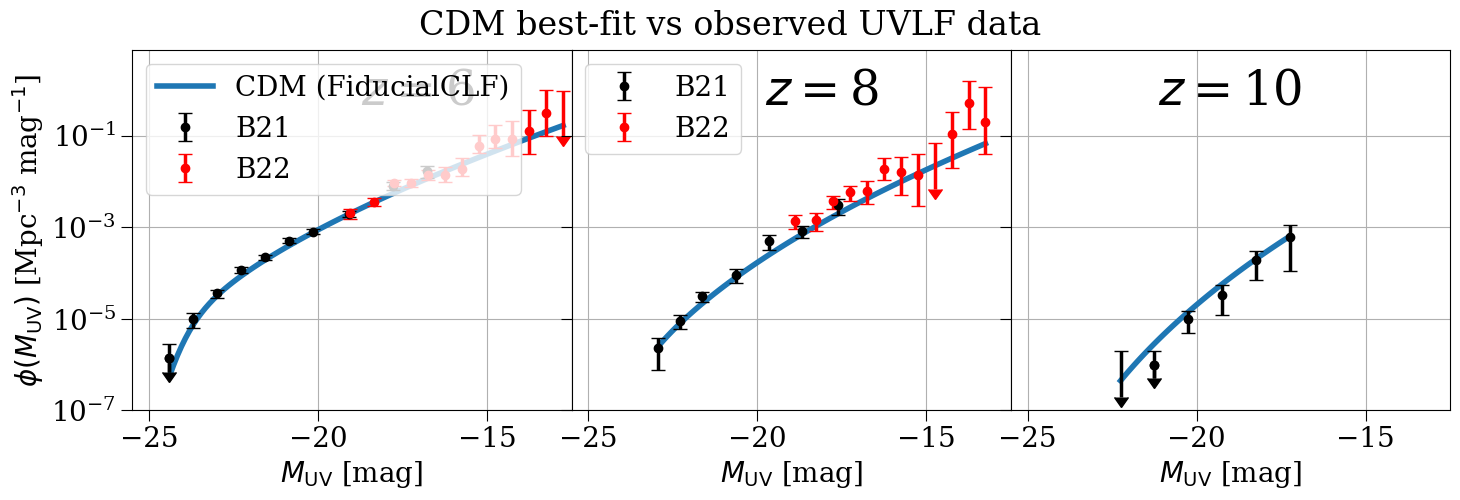

In [5]:
# Plot the CDM model fit vs data using LFPlotter
plotter_cdm = LFPlotter(
    [path + 'FiducialCLF'],
    ModelClass=[FiducialCLF],
    names=['CDM (FiducialCLF)']
)
plotter_cdm.plot_fits(eval_z=[6, 8, 10], n_col=3, figsize=(15, 5))
plt.suptitle('CDM best-fit vs observed UVLF data', y=1.02)
plt.show()

## 4. Adding FDM: the `dn_dM` Override

`ReciprocalFuzzyCLF` extends the CDM model with one additional parameter: $1/m_{22}$
(the inverse of the FDM particle mass in units of $10^{-22}$ eV).

The only change is in `dn_dM`: it multiplies the CDM mass function by a
**Schive suppression factor**:

$$\frac{dn}{dM}\bigg|_{\rm FDM} = \frac{dn}{dM}\bigg|_{\rm CDM} \cdot \left(1 + \left(\frac{M}{M_0}\right)^{-1.1}\right)^{-2.2}$$

where $M_0 = 1.6 \times 10^{10} \, m_{22}^{-4/3} \, M_\odot$ is the half-mode mass.

This suppresses the abundance of low-mass halos — lighter FDM particles (smaller $m_{22}$)
suppress more halos.

Here's the entire class (from `lf_model.py`):

```python
class ReciprocalFuzzyCLF(LFModel):
    N_PARAMS = 6
    MCMC_PRIOR = [[0.8, 3.5], [0.8, 2.5], [0, 2.5], [-25, -20], [10, 14], [0, 2]]

    def __init__(self, meas_fn, params, dc=True, name=None, f_esc=0.2, log_input=True):
        super().__init__(meas_fn, params, dc, name, f_esc)
        self.p, self.q, self.r, self.L0, self.M1, self.one_over_m_FDM22 = params
        if log_input:
            self.L0 = utils.m_to_L(self.L0)
            self.M1 = 10**self.M1
        self.m_FDM22 = 1 / self.one_over_m_FDM22
        self.M0_schive = 1.6e10 * self.m_FDM22**(-4/3)

    def dn_dM(self, M, z):
        return self.mass_fn[z](M) * (1 + (M/self.M0_schive)**-1.1)**-2.2

    def L_c(self, M, z):
        return np.clip(
            self.L0 * (M/self.M1)**self.p / (1+(M/self.M1)**self.q) * ((1+z)/7)**self.r,
            a_max=self.L_c_max(M, z), a_min=0)
```

Note: `self.mass_fn` is loaded automatically by `LFModel.__init__()` from `mass_fns.npz`.

## 5. Visualizing the Effect of FDM Mass

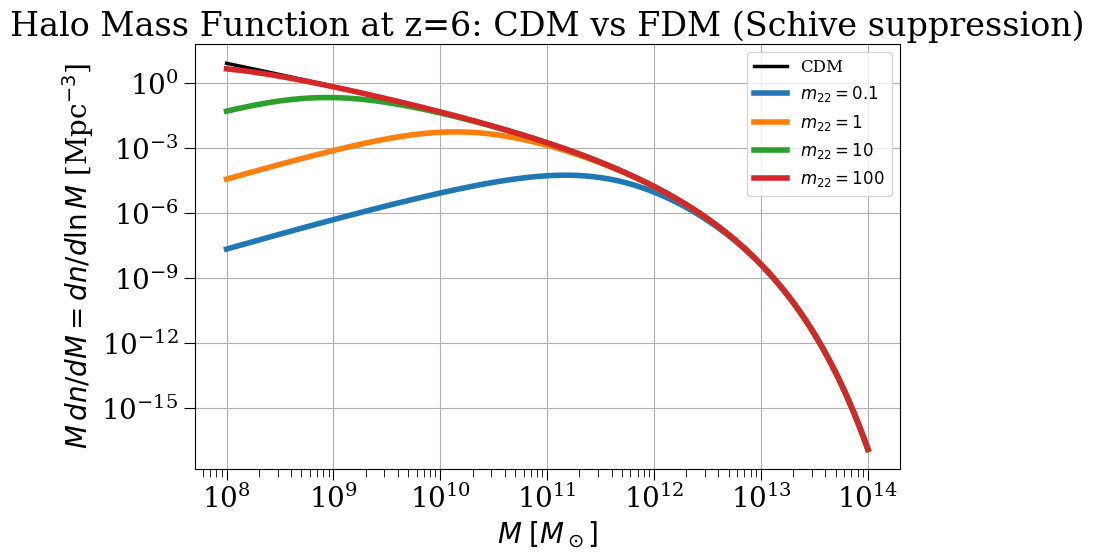

In [6]:
# Show the HMF suppression at different m22 values
# Plot M * dn/dM (= dn/dlnM), which is the more standard way to visualize
# since it shows the mass contribution per log interval.
m22_values = [0.1, 1, 10, 100]

plt.figure(figsize=(9, 6))
plt.loglog(M_vals, [M * mf[6](M) for M in M_vals], 'k-', lw=2.5, label='CDM')

for m22 in m22_values:
    M0 = 1.6e10 * m22**(-4/3)
    dn_dlnM_fdm = [M * mf[6](M) * (1 + (M/M0)**-1.1)**-2.2 for M in M_vals]
    plt.loglog(M_vals, dn_dlnM_fdm, label=f'$m_{{22}}={m22}$')

plt.xlabel(r'$M\;[M_\odot]$')
plt.ylabel(r'$M \, dn/dM = dn/d\ln M$ [Mpc$^{-3}$]')
plt.legend(fontsize=12)
plt.title('Halo Mass Function at z=6: CDM vs FDM (Schive suppression)')
plt.tight_layout()
plt.show()

/root/fdm-uvlf/lf_model.py:865: RuntimeWarning: divide by zero encountered in scalar divide
  self.m_FDM22 = 1/self.one_over_m_FDM22
/root/fdm-uvlf/lf_model.py:869: RuntimeWarning: divide by zero encountered in scalar divide
  return self.mass_fn[z](M) * (1 + (M/self.M0_schive)**-1.1)**-2.2


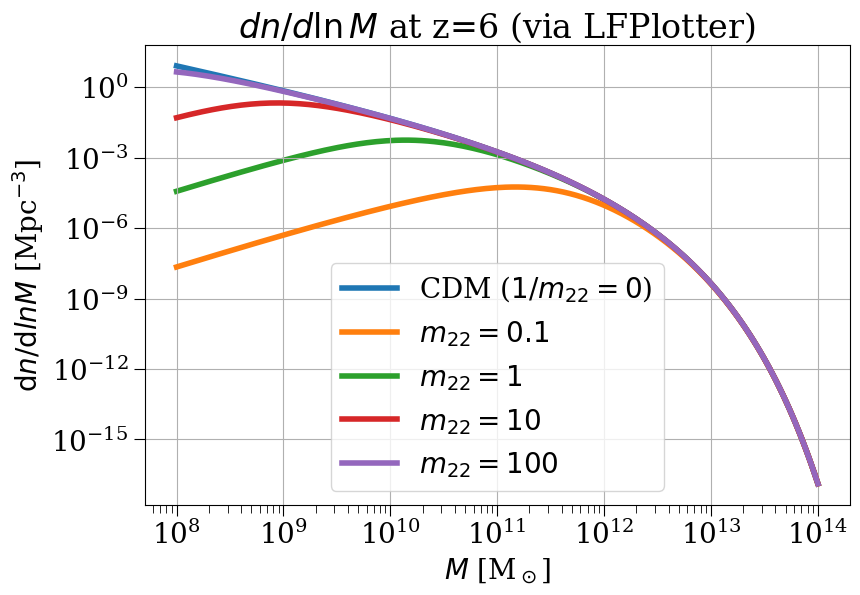

/root/fdm-uvlf/lf_model.py:869: RuntimeWarning: divide by zero encountered in divide
  return self.mass_fn[z](M) * (1 + (M/self.M0_schive)**-1.1)**-2.2


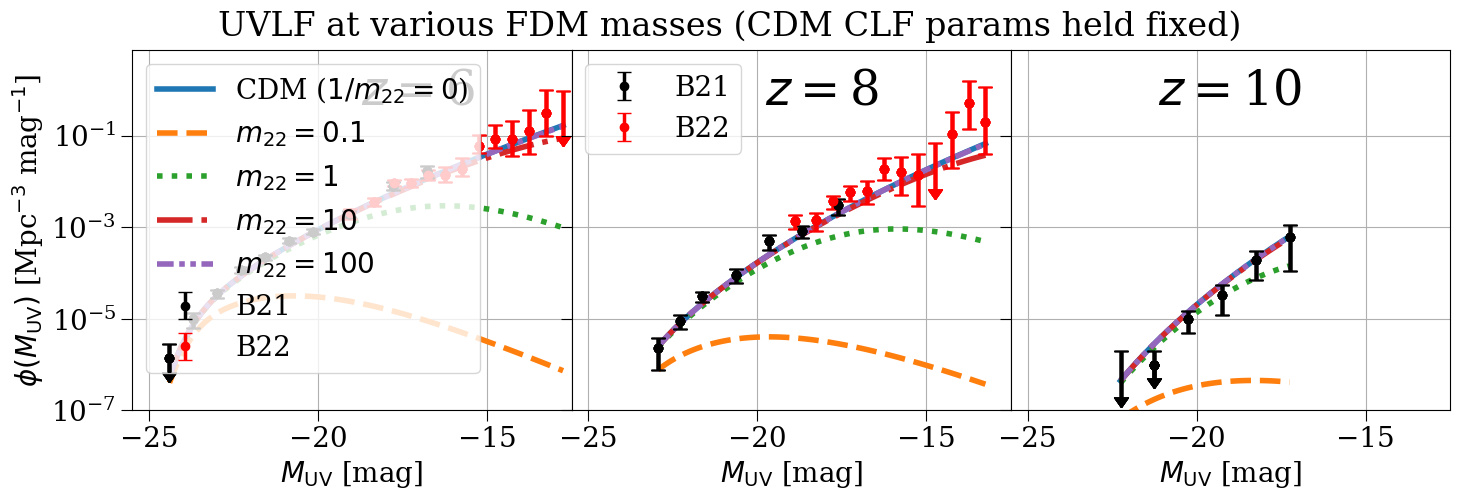

In [7]:
# Same comparison using LFPlotter.plot_dn_dlnM (built-in, plots M*dn/dM)
# Use ReciprocalFuzzyCLF for all models: 1/m22=0 is the CDM limit
dirs = [path + 'FiducialCLF'] * (1 + len(m22_values))
names = ['CDM ($1/m_{22}=0$)'] + [f'$m_{{22}}={m22}$' for m22 in m22_values]
classes = [ReciprocalFuzzyCLF] * (1 + len(m22_values))
manual_p = [list(params_cdm) + [0.0]] + [list(params_cdm) + [1.0/m22]
                                         for m22 in m22_values]

plotter_fdm_grid = LFPlotter(
    dirs,
    ModelClass=classes,
    names=names,
    manual_params=manual_p
)
plotter_fdm_grid.plot_dn_dlnM(z_vals=[6], M_vals=np.logspace(8, 14, 200))
plt.title('$dn/d\\ln M$ at z=6 (via LFPlotter)')
plt.show()

# Show the resulting UVLF at different m22 values
plotter_fdm_grid.plot_fits(eval_z=[6, 8, 10], n_col=3, figsize=(15, 5))
plt.suptitle('UVLF at various FDM masses (CDM CLF params held fixed)', y=1.02)
plt.show()

## 6. Optimization

Before running MCMC, you typically find the best-fit parameters using scipy's Nelder-Mead
optimizer. The `LFOptimizer` class wraps this:

```python
opt = LFOptimizer(
    meas_fn='path/to/meas.npz',   # measurement data
    ModelClass=ReciprocalFuzzyCLF, # which model to fit
    x0=initial_guess,              # starting parameter vector
    prior=bounds                   # parameter bounds [[lo, hi], ...]
)
result = opt.optimize_loop()  # runs Nelder-Mead a few times
```

**Important**: `optimize_loop()` returns the result in memory. It does NOT save to disk.
Only `run_optimize(directories)` writes `best.npy` — avoid that if you don't want to
overwrite saved results.

In [8]:
# Optimize CDM model starting from the saved best-fit
opt_cdm = LFOptimizer(
    meas_fn=path + 'FiducialCLF/meas.npz',
    ModelClass=FiducialCLF,
    x0=params_cdm.copy(),
    prior=FiducialCLF.MCMC_PRIOR
)
result_cdm = opt_cdm.optimize_loop()
print(f"Converged: {result_cdm.success}")
print(f"chi^2 = {result_cdm.fun:.2f}")
print(f"Best-fit params: {result_cdm.x}")

Converged: True
chi^2 = 178.83
Best-fit params: [  1.69805254   1.5424178    1.12067863 -23.7784511   11.92153786]


In [9]:
# Optimize FDM model (ReciprocalFuzzyCLF)
params_fdm = np.load(path + 'ReciprocalFuzzyCLF/best.npy')
print(f"Saved FDM best-fit: {params_fdm}")
print(
    f"  (last param is 1/m22 = {params_fdm[-1]:.4f}, i.e. m22 = {1/params_fdm[-1]:.1f})")

opt_fdm = LFOptimizer(
    meas_fn=path + 'ReciprocalFuzzyCLF/meas.npz',
    ModelClass=ReciprocalFuzzyCLF,
    x0=params_fdm.copy(),
    prior=ReciprocalFuzzyCLF.MCMC_PRIOR
)
result_fdm = opt_fdm.optimize_loop()
print(f"\nOptimized chi^2 = {result_fdm.fun:.2f}")
print(f"Optimized params: {result_fdm.x}")
print(f"  1/m22 = {result_fdm.x[-1]:.4f} → m22 = {1/result_fdm.x[-1]:.1f}")
print("\nNote: best-fit FDM is near CDM limit (large m22). The interesting")
print("physics is in the POSTERIOR — how much FDM mass is excluded.")

Saved FDM best-fit: [ 1.69802680e+00  1.54250505e+00  1.12075324e+00 -2.37785838e+01
  1.19215873e+01  1.86993263e-07]
  (last param is 1/m22 = 0.0000, i.e. m22 = 5347786.2)

Optimized chi^2 = 178.83
Optimized params: [ 1.69805722e+00  1.54238129e+00  1.12071162e+00 -2.37784254e+01
  1.19215272e+01  1.90494634e-07]
  1/m22 = 0.0000 → m22 = 5249491.7

Note: best-fit FDM is near CDM limit (large m22). The interesting
physics is in the POSTERIOR — how much FDM mass is excluded.


## 7. MCMC Sampling

The real result is the **posterior distribution** over parameters — especially
the FDM mass constraint. We use `emcee` (affine-invariant ensemble sampler).

The likelihood is:
$$\ln p(\theta | \text{data}) = -\frac{1}{2} \chi^2(\theta) + \ln \pi(\theta)$$

where $\pi(\theta)$ is a flat prior within the bounds (`MCMC_PRIOR`).

### Running a short demo chain

A real production run uses ~5000 steps × 96 walkers and takes hours.
Here we run 200 steps × 24 walkers (~5-10 min) to demonstrate the workflow.
The chain won't be converged but will show the mechanics.

In [10]:
import emcee
import os
os.environ['OMP_NUM_THREADS'] = '1'

# Set up the sampler — in-memory only, no .h5 file
n_walkers = 24
n_dim = ReciprocalFuzzyCLF.N_PARAMS  # 6
n_steps = 200

# Initialize walkers in a small ball around the best-fit
x0 = result_fdm.x
# [[lo, hi], ...] for each param
prior = np.array(ReciprocalFuzzyCLF.MCMC_PRIOR)

# Clip initial positions to stay within prior bounds
pos = x0 + 0.05 * np.random.randn(n_walkers, n_dim)
pos = np.clip(pos, prior[:, 0] + 1e-6, prior[:, 1] - 1e-6)

# The log-probability function used by emcee
# opt_fdm.log_prob(x) = -0.5 * chi_sq(x) + log_prior(x)
sampler = emcee.EnsembleSampler(n_walkers, n_dim, opt_fdm.log_prob)

print(
    f"Running MCMC: {n_walkers} walkers × {n_steps} steps ({n_walkers * n_steps} evaluations)")
sampler.run_mcmc(pos, n_steps, progress=True)
print(
    f"\nDone. Mean acceptance fraction: {np.mean(sampler.acceptance_fraction):.2f}")

Running MCMC: 24 walkers × 200 steps (4800 evaluations)


You must install the tqdm library to use progress indicators with emcee
/root/fdm-uvlf/lf_model.py:866: RuntimeWarning: invalid value encountered in scalar power
  self.M0_schive = 1.6e10 * self.m_FDM22**(-4/3)



Done. Mean acceptance fraction: 0.49


## 8. Reading Back Chains & Making Plots

The chain is stored as a 3D array: `(n_steps, n_walkers, n_params)`.

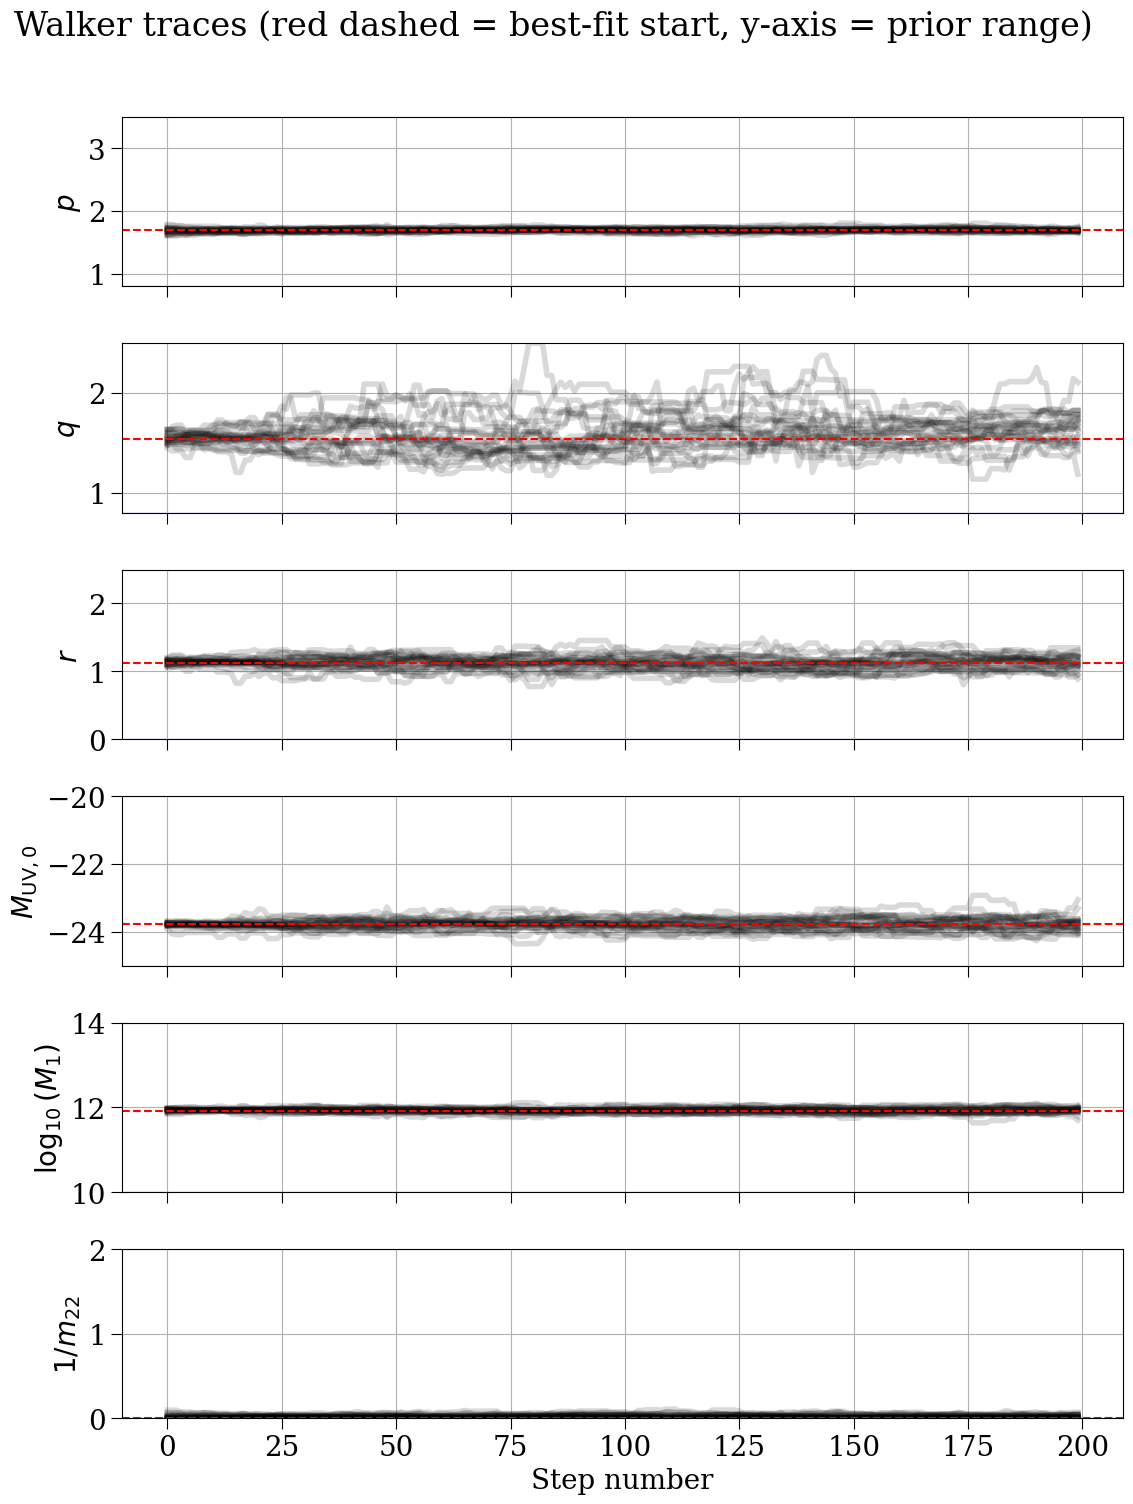

In [11]:
# Walker traces — check for mixing and convergence
# (This is what LFPlotter.plot_corner(..., walkers=True) does internally
#  when reading from an HDF5 backend.)
chain = sampler.get_chain()  # shape: (n_steps, n_walkers, n_dim)
labels = [r'$p$', r'$q$', r'$r$',
          r'$M_{\rm UV,0}$', r'$\log_{10}(M_1)$', r'$1/m_{22}$']

fig, axes = plt.subplots(n_dim, figsize=(12, 2.5 * n_dim), sharex=True)
for i in range(n_dim):
    ax = axes[i]
    ax.plot(chain[:, :, i], 'k', alpha=0.15)
    ax.axhline(x0[i], color='red', ls='--', lw=1.5)
    ax.axhspan(prior[i, 0], prior[i, 0], color='blue', alpha=0.3)
    ax.set_ylim(prior[i, 0], prior[i, 1])
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel('Step number')
plt.suptitle(
    'Walker traces (red dashed = best-fit start, y-axis = prior range)', y=1.01)
plt.tight_layout()
plt.show()

Samples after burn-in: 2400


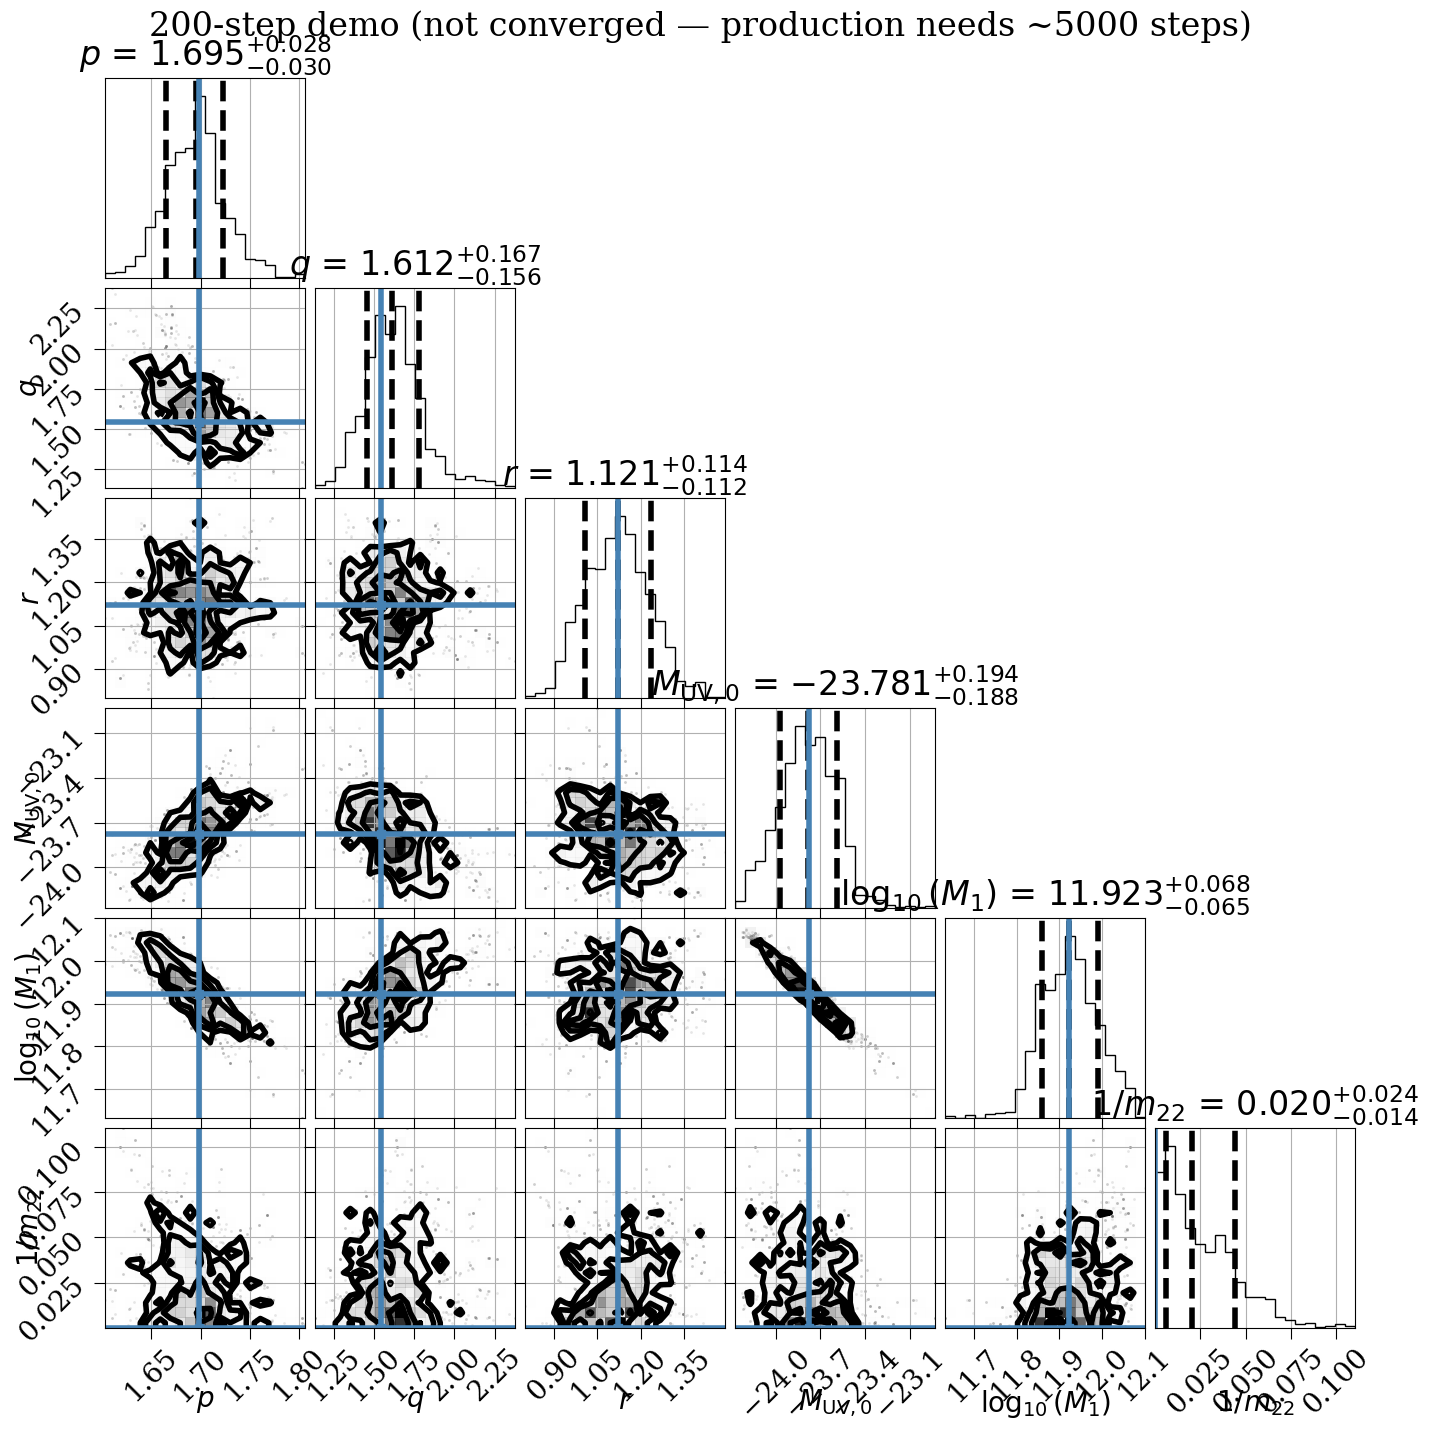

In [12]:
# Corner plot — joint and marginal posteriors
# NOTE: For production runs saved to HDF5 files, use LFPlotter.plot_corner(burn_in=15000, walkers=True)
# which reads from the HDF5 backend and also plots walker traces + autocorrelation times.
# Here we use corner.corner() directly on in-memory samples for this demo.
import corner

# Discard first ~half as burn-in for this short chain
burn_in = n_steps // 2
flat_samples = sampler.get_chain(discard=burn_in, flat=True)
print(f"Samples after burn-in: {flat_samples.shape[0]}")

fig = corner.corner(
    flat_samples,
    labels=labels,
    truths=x0,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt='.3f'
)
plt.suptitle(
    f'{n_steps}-step demo (not converged — production needs ~5000 steps)', y=1.02)
plt.show()

1/m22 range in chain: [0.0000, 0.1106]
  (prior bounds: [0, 2])

FDM mass lower bounds (illustrative, NOT converged):
  1-sigma: m22 > 48.7
  2-sigma: m22 > 89.2


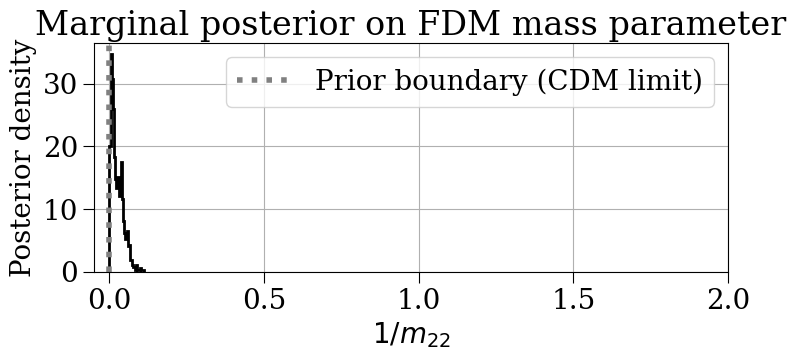

In [13]:
# Extract the FDM mass constraint (the key science result)
# The sampled parameter is 1/m22, bounded to [0, 2] by the prior.
# Smaller 1/m22 → heavier FDM → less suppression → closer to CDM.
inv_m22_samples = flat_samples[:, -1]
print(
    f"1/m22 range in chain: [{inv_m22_samples.min():.4f}, {inv_m22_samples.max():.4f}]")
print(f"  (prior bounds: [0, 2])")

# Convert to m22 (only for samples where 1/m22 > 0)
valid = inv_m22_samples > 0.01
m22_samples = 1.0 / inv_m22_samples[valid]
percentiles = np.percentile(m22_samples, [68, 95, 99.7])
print(f"\nFDM mass lower bounds (illustrative, NOT converged):")
print(f"  1-sigma: m22 > {percentiles[0]:.1f}")
print(f"  2-sigma: m22 > {percentiles[1]:.1f}")

plt.figure(figsize=(8, 4))
plt.hist(inv_m22_samples, bins=30, density=True,
         histtype='step', lw=2, color='k')
plt.axvline(x=0, color='gray', ls=':', label='Prior boundary (CDM limit)')
plt.xlabel(r'$1/m_{22}$')
plt.ylabel('Posterior density')
plt.title('Marginal posterior on FDM mass parameter')
plt.legend()
plt.xlim(-0.05, prior[-1, 1])
plt.tight_layout()
plt.show()

### Production MCMC: the full recipe

The short chain above is just a demo. For real science results, you need a
converged chain (~5000 steps × 96 walkers, taking hours). The repo has a
ready-made function for this in `lf_optimizer.py`.

**The complete production workflow is 3 steps:**

```python
from lf_optimizer import LFOptimizer, run_mcmc
from lf_model import ReciprocalFuzzyCLF

# Step 1: Optimize to find the best-fit
# (We already did this above with opt_fdm.optimize_loop())
# save it: np.save('./lf/by_name/ReciprocalFuzzyCLF/best.npy', result.x)

# Step 2: Run the production MCMC chain
# This writes mcmc.h5 to the model directory and uses multiprocessing.
# IMPORTANT: you must pass x0 and prior — they are NOT auto-detected from the model class.
run_mcmc(
    ['./lf/by_name/ReciprocalFuzzyCLF'],
    ModelClass=ReciprocalFuzzyCLF,
    x0=ReciprocalFuzzyCLF.MCMC_X0,        # or your optimized best-fit values
    prior=ReciprocalFuzzyCLF.MCMC_PRIOR,   # bounds for the flat prior
    n_steps=5000,    # 5000 steps is typical
    reset=True       # False to resume an existing chain
)

# Step 3: Plot results using LFPlotter
from lf_plotter import LFPlotter
plotter = LFPlotter(['./lf/by_name/ReciprocalFuzzyCLF'], ModelClass=[ReciprocalFuzzyCLF])
plotter.plot_corner(burn_in=1000, walkers=True)  # corner plot + walker traces
plotter.plot_fits(eval_z=[6, 8, 10])             # UVLF fits with error bands
```

**About `x0` and `prior` — each model class carries its own defaults:**

Every `LFModel` subclass defines `MCMC_X0` (a reasonable starting point) and
`MCMC_PRIOR` (flat prior bounds) as class attributes. For example:
```python
ReciprocalFuzzyCLF.MCMC_X0    # [1.24, 1, 1.5, -21.91, 12.08, 0.1]
ReciprocalFuzzyCLF.MCMC_PRIOR # [[0.8, 3.5], [0.8, 2.5], ...]
```
However, `LFOptimizer` does **not** automatically pull these from the model class —
you must pass them explicitly as `x0=` and `prior=`. (If you don't, it falls back
to hardcoded defaults at the top of `lf_optimizer.py` that only match `FiducialCLF`.)

In practice, you might want `x0` to be the optimized
best-fit (from Step 1), not `MCMC_X0`, but you risk starting in a deep local minimum, so maybe try both. The walkers are initialized as a Gaussian
ball around `x0`.

**What `run_mcmc` does internally** (see `lf_optimizer.py` lines 107-144):
1. Creates an `LFOptimizer(meas_fn, ModelClass, x0=x0, prior=prior)`
2. Initializes 96 walkers in a Gaussian ball (σ=0.1) around `x0`
3. Sets up an HDF5 backend (`mcmc.h5`) so the chain saves incrementally
4. Runs `emcee.EnsembleSampler` with multiprocessing and a mix of 5 move types
5. If `reset=False`, resumes from where the chain left off (useful if interrupted)

**What each directory needs:**
- `meas.npz` — the observational data (already exists for all models)
- `best.npy` — best-fit parameters (used by `LFPlotter`, not by `run_mcmc` itself)
- `mcmc.h5` — the chain file (created by `run_mcmc()`)

**To read back a saved chain manually:**
```python
reader = emcee.backends.HDFBackend('./lf/by_name/ReciprocalFuzzyCLF/mcmc.h5')
flat_samples = reader.get_chain(discard=1000, flat=True)
```

## 9. Writing Your Own Model

To use a different halo mass function, you subclass `LFModel` and override `dn_dM`.
Everything else (the CLF, chi-squared, optimizer, MCMC) works unchanged.

### Example: a toy "step-function" suppression

In [14]:
class StepFunctionFDM(LFModel):
    """Toy model: suppress all halos below a cutoff mass M_cut."""
    N_PARAMS = 6
    MCMC_PRIOR = [[0.8, 3.5], [0.8, 2.5], [
        0, 2.5], [-25, -20], [10, 14], [8, 12]]

    def __init__(self, meas_fn, params, dc=True, name=None, f_esc=0.2, log_input=True):
        super().__init__(meas_fn, params, dc, name, f_esc)
        self.param_names = [r'$p$', r'$q$', r'$r$',
                            r'$M_{\rm UV,0}$', r'$\log_{10}(M_1)$', r'$\log_{10}(M_{\rm cut})$']
        self.p, self.q, self.r, self.L0, self.M1, self.log_M_cut = params
        if log_input:
            self.L0 = utils.m_to_L(self.L0)
            self.M1 = 10**self.M1
        self.M_cut = 10**self.log_M_cut

    def dn_dM(self, M, z):
        # Hard cutoff below M_cut (toy example — not physical)
        # Must handle array input since trapz_integrate passes arrays
        return np.where(M < self.M_cut, 0.0, self.mass_fn[z](M))

    def L_c(self, M, z):
        return np.clip(
            self.L0 * (M/self.M1)**self.p /
            (1 + (M/self.M1)**self.q) * ((1+z)/7)**self.r,
            a_max=self.L_c_max(M, z), a_min=0)


# Test it: step-function cutoff at M_cut = 10^9.5 M_sun
test_params = list(params_cdm) + [9.5]
model_step = StepFunctionFDM(path + 'FiducialCLF/meas.npz', test_params)
print(f"Step-function model chi^2 = {model_step.chi_sq_of_model():.2f}")
print(f"(Compare CDM chi^2 = {model_cdm.chi_sq_of_model():.2f})")

Step-function model chi^2 = 184.09


(Compare CDM chi^2 = 178.83)


/root/fdm-uvlf/utils.py:148: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)


In [15]:
# Optimize the step-function model
opt_step = LFOptimizer(
    meas_fn=path + 'FiducialCLF/meas.npz',
    ModelClass=StepFunctionFDM,
    x0=test_params,
    prior=StepFunctionFDM.MCMC_PRIOR
)
result_step = opt_step.optimize_loop()
print(f"Optimized chi^2 = {result_step.fun:.2f}")
print(f"Best-fit log10(M_cut) = {result_step.x[-1]:.2f}")
print(f"  → M_cut = {10**result_step.x[-1]:.2e} M_sun")

Optimized chi^2 = 178.83
Best-fit log10(M_cut) = 8.99
  → M_cut = 9.69e+08 M_sun


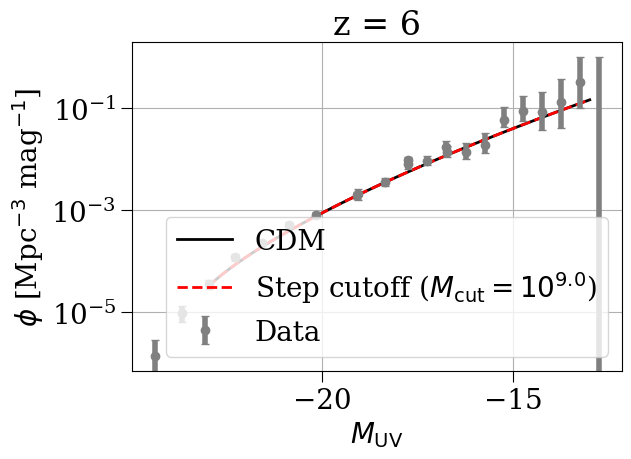

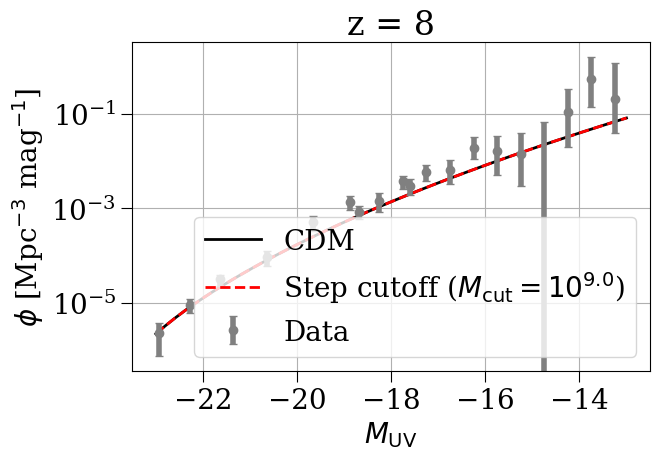

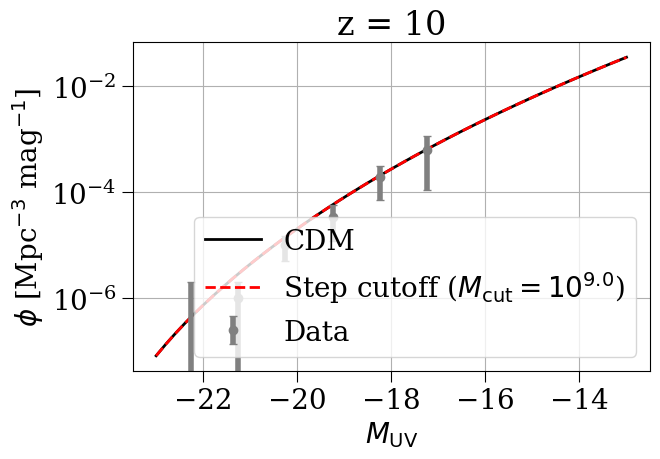

In [16]:
# Compare UVLF predictions: CDM vs step-function model
model_step_opt = StepFunctionFDM(path + 'FiducialCLF/meas.npz', result_step.x)

for z in [6, 8, 10]:
    mags_plot = np.linspace(-23, -13, 50)
    phi_cdm = [model_cdm.phi_m(m, z) for m in mags_plot]
    phi_step = [model_step_opt.phi_m(m, z) for m in mags_plot]

    plt.figure(figsize=(7, 5))
    plt.semilogy(mags_plot, phi_cdm, 'k-', lw=2, label='CDM')
    plt.semilogy(mags_plot, phi_step, 'r--', lw=2,
                 label=f'Step cutoff ($M_{{\\rm cut}}=10^{{{result_step.x[-1]:.1f}}}$)')

    # Overlay data points (meas attributes are lists, so extract per-z)
    data_m = [mag for (z_v, mag, phi, sm, sp, src) in meas.zipped if z_v == z]
    data_phi = [phi for (z_v, mag, phi, sm, sp, src) in meas.zipped if z_v == z]
    data_sm = [sm for (z_v, mag, phi, sm, sp, src) in meas.zipped if z_v == z]
    data_sp = [sp for (z_v, mag, phi, sm, sp, src) in meas.zipped if z_v == z]
    plt.errorbar(data_m, data_phi, yerr=[data_sm, data_sp],
                 fmt='o', color='gray', capsize=3, label='Data')
    plt.xlabel(r'$M_{\rm UV}$')
    plt.ylabel(r'$\phi$ [Mpc$^{-3}$ mag$^{-1}$]')
    plt.legend()
    plt.title(f'z = {z}')
    plt.tight_layout()
    plt.show()

### More realistic: using your own HMF

In practice, you'd replace the step function with a physically-motivated HMF.
There are three approaches:

#### Option A: Analytic fitting function (simplest)

Like the Schive suppression in `ReciprocalFuzzyCLF` — multiply the CDM mass function
by an analytic suppression factor. Fast, no precomputation needed.

#### Option B: Precompute on a grid (most flexible)

Use `mass_function.MassFunction` to compute your HMF on a grid of (M, z) values,
save as `.npz`, and load+interpolate in your model. This is how `mass_fns.npz` was
originally created:

```python
from mass_function import MassFunction
import numpy as np
import utils

# Compute the HMF (this takes a few minutes)
mf = MassFunction(load=True)  # loads P_k.npz; set load=False to recompute from CAMB

# Evaluate on a grid
Mvals = np.logspace(7, 16, 2000)
mf_dict = {'Mvals': Mvals}
for z in range(0, 20):
    mf_dict[str(z)] = [mf.dndM(M, z=z) for M in Mvals]

# Save in the format that utils.load_mf() expects
np.savez('my_custom_mass_fns.npz', **mf_dict)

# Verify it loads correctly
mass_fns = utils.load_mf('my_custom_mass_fns.npz')
# mass_fns[6](1e10) gives dn/dM at z=6, M=10^10 Msun
```

For an FDM mass function, pass `m_FDM` to `MassFunction`:
```python
mf_fdm = MassFunction(load=True, m_FDM=1e-22)  # sets up FDM transfer function
```

Then in your model class, load your custom grid:
```python
class MyModel(LFModel):
    def __init__(self, meas_fn, params, ...):
        super().__init__(meas_fn, params, ...)
        self.mass_fn = utils.load_mf('my_custom_mass_fns.npz')
```

#### Option C: The Marsh approach (parameterized grid)

See `MarshCLF` in `lf_model.py` — it loads a precomputed grid from
`lf/marsh_mf/*.npz` that was generated at many FDM masses, then interpolates
between them. This is useful when your HMF depends on a free parameter that
varies during MCMC.

#### Key requirement

`dn_dM(self, M, z)` must handle **array input** (numpy arrays of M values)
and be reasonably fast, since it's called ~1000 times per chi-squared
evaluation (once per integration point per redshift bin).

---

### Checklist for a new model

1. Subclass `LFModel`
2. Set `N_PARAMS` and `MCMC_PRIOR`
3. In `__init__`: unpack your parameters from the `params` vector
4. Override `dn_dM(self, M, z)` with your HMF
5. Override `L_c(self, M, z)` (or copy from `FiducialCLF` if you're only changing the HMF)
6. Create an `LFOptimizer` with your class and run `optimize_loop()`
7. Feed the optimizer to `emcee` for MCMC

---

## Code Walkthrough: Key Functions to Explain

When walking someone through this codebase, these are the specific functions/lines
worth opening up and explaining. They form the "spine" of the pipeline.

---

### `lf_model.py` — `LFModel.__init__` (line 212)

```python
class LFModel:
    def __init__(self, meas_fn, params, dc=True, name=None, f_esc=0.2):
        self.meas = LFMeasurements(self.meas_fn, dc=dc)  # loads observed data
        self.sigma = lambda M: np.log(10)*0.16            # scatter in L-M relation (fixed 0.16 dex)
        self.mass_fn = utils.load_mf()                    # CDM halo mass function dict {z: interp(M)}
```

**Why it matters**: Every model starts here. Point out that `self.mass_fn` is the CDM
baseline that subclasses can override, and `self.sigma` is the log-normal scatter
(fixed at 0.16 dex — from Behroozi+15).

---

### `lf_model.py` — `LFModel.dn_dM` (line 241)

```python
def dn_dM(self, M, z):
    ''' Halo mass function.'''
    return self.mass_fn[z](M)
```

**Why it matters**: This is THE extension point. CDM just returns the precomputed
interpolator. FDM subclasses override this single method to apply suppression.
Emphasize: if you have a new HMF, this is the only function you *must* change.

---

### `lf_model.py` — `LFModel.phi_L_given_M` (line 295)

```python
def phi_L_given_M(self, L, M, z):
    prefactor = 1/(np.sqrt(2*np.pi)*self.sigma(M)*L)
    exponent = -np.log(L/self.L_c(M, z))**2 / (2*self.sigma(M)**2)
    return prefactor * np.exp(exponent)
```

**Why it matters**: This is the log-normal CLF — "given a halo of mass M, what's the
probability it has luminosity L?" The median luminosity `L_c(M, z)` is the other
free-parameter function that subclasses define. The 0.16 dex scatter (`self.sigma`)
means ~40% spread around the median.

---

### `lf_model.py` — `LFModel.phi_L` (line 302)

```python
def phi_L(self, L, z):
    lo, hi = 1e8, 1e15
    def integrand(M): return self.dn_dM(M, z) * self.phi_L_given_M(L, M, z)
    return utils.trapz_integrate(integrand, lo, hi, logspace=True)
```

**Why it matters**: This is the core integral — marginalize over halo mass to get the
observed luminosity function. "How many galaxies have luminosity L at redshift z?"
= sum over all halos (weighted by HMF) of the probability each halo produces that luminosity.
Note: integrated in log-space for numerical stability (halos span 7 orders of magnitude).

---

### `lf_model.py` — `FiducialCLF.L_c` (line 581)

```python
def L_c(self, M, z):
    return self.L0 * (M/self.M1)**self.p / (1+(M/self.M1)**self.q) * ((1+z)/7)**self.r
```

**Why it matters**: The 5-parameter CLF ansatz. Walk through each piece:
- `L0` — overall normalization (expressed as M_UV,0 in the parameter vector)
- `M1` — characteristic halo mass where the relation turns over
- `p` — faint-end slope (low-mass halos: L ∝ M^p)
- `q` — controls the turnover (high-mass halos: L ∝ M^(p-q))
- `r` — redshift evolution: ((1+z)/7)^r
- Note `log_input=True` means params come in as [p, q, r, M_UV, log10(M1)]
  and get converted via `m_to_L` and `10**`

---

### `lf_model.py` — `ReciprocalFuzzyCLF.dn_dM` (line 868)

```python
def dn_dM(self, M, z):
    return self.mass_fn[z](M) * (1 + (M/self.M0_schive)**-1.1)**-2.2
```

where `self.M0_schive = 1.6e10 * self.m_FDM22**(-4/3)`

**Why it matters**: The complete FDM modification in one line. The suppression factor
goes to 1 for M >> M0 (heavy halos unaffected) and to 0 for M << M0 (light halos
wiped out). The exponents (-1.1, -2.2) come from Schive+16 N-body simulations.
M0 depends on particle mass as m22^(-4/3): lighter FDM → larger M0 → more suppression.

---

### `lf_model.py` — `LFModel.chi_sq_of_model` (line 486)

```python
for z in self.meas.unique_z:
    mags = [mag for (mag, z_val) in mags_and_zs if z_val == z]
    predicted_phis = [self.phi_m(mag, z) for mag in mags]
    ...
    self.chi_dict.update({z: sum([utils.chi_squared(*args) for args in chi_input])})
return sum(self.chi_dict.values())
```

**Why it matters**: This is the likelihood evaluation. For each redshift, for each
observed magnitude bin, call `phi_m` to get the model prediction, then compute
chi-squared against the data. The total chi-squared is summed over all (mag, z) points.
This is what the optimizer minimizes and what enters the MCMC log-probability.

---

### `utils.py` — `chi_squared` (line 214)

```python
def chi_squared(measured, theory, sigma_plus, sigma_minus=None):
    sigma = 2 * sigma_plus * sigma_minus / (sigma_plus + sigma_minus)
    sigma_prime = (sigma_plus - sigma_minus) / (sigma_plus + sigma_minus)
    denominator = (sigma + sigma_prime*(theory - measured))**2
    return (measured - theory)**2 / denominator
```

**Why it matters**: Handles asymmetric error bars. Not just (data-model)²/σ² — it uses
a generalized form where σ_eff depends on which side of the data the theory falls.
Also handles upper-limit-only points (sigma_minus=0) via half-normal.

---

### `utils.py` — `trapz_integrate` (line 201)

```python
def trapz_integrate(integrand, lo, hi, n_intervals=1000, logspace=False):
    if logspace:
        lo, hi = np.log(lo), np.log(hi)
        def integrand_fn(logx): return np.exp(logx) * integrand(np.exp(logx))
    x = np.linspace(lo, hi, n_intervals)
    y = integrand_fn(x)
    return trapz(y=y, x=x)
```

**Why it matters**: Almost all integrals in the pipeline use this. The `logspace=True`
flag means it integrates ∫f(M)dM by substituting x=log(M), so dx spacing is uniform
in log-space — crucial when integrating from 10^8 to 10^15 M_sun.

---

### `lf_optimizer.py` — `LFOptimizer.log_prob` (line 94)

```python
def log_prob(self, x):
    ln_pri = self.log_prior(x)
    chi_sq = self.get_chi_sq(x)
    ln_prob = -0.5 * chi_sq + ln_pri
    return ln_prob
```

**Why it matters**: This is what emcee samples. The connection between chi-squared
and log-likelihood is just: ln(L) = -χ²/2. The prior is flat within bounds
(returns 0 inside, -∞ outside). So MCMC explores the parameter space weighted by
exp(-χ²/2) — regions of low chi-squared get more samples.

---

### Suggested presentation order

1. Start with the **data** (`LFMeasurements`) — "here's what we're fitting"
2. Show `FiducialCLF.L_c` — "here's our model for galaxy brightness vs halo mass"
3. Show `phi_L_given_M` → `phi_L` → `phi_m` — "here's how we predict the observable"
4. Show `dn_dM` in base class — "this is where the halo mass function enters"
5. Show `ReciprocalFuzzyCLF.dn_dM` — "this is the ONE LINE that changes for FDM"
6. Show `chi_sq_of_model` — "this is how we score the fit"
7. Show `LFOptimizer.log_prob` — "this is what MCMC samples"
8. Show how to write your own `dn_dM` — "now you do it"

---

## Further Reading

- `lf_model.py` — all model classes; `LFModel` base class has the full forward model
- `mass_function.py` — `MassFunction` class for computing HMFs from first principles
- `lf_optimizer.py` — `run_mcmc()` for production MCMC runs with HDF5 backends
- `lf_plotter.py` — `LFPlotter` for publication-quality plots (corner, fits, etc.)
- `utils.py` — cosmological constants, interpolation helpers
- `*.ipynb` — other notebooks